# Per-copy energy slope vs single-copy measurements — cutoffs and batch-size tiers

Each measured **batch** runs `N` copies of one query inside a *single* `psql` process.
Package energy (`rapl_pkg_j`) and wall time (`elapsed_sec`) are read **once** around the
whole process, so a batch is

$$E(N) \;=\; \underbrace{a}_{\text{fixed per-process cost}} \;+\; \underbrace{b}_{\text{per-copy cost}}\cdot N .$$

A straight-line fit of energy against `N` separates the two: the **slope** `b` is the
energy of one more warm copy, and the **intercept** `a` is the per-process overhead
(sudo, `psql` start, connect, teardown) paid once per batch. This notebook asks how far a
single-copy (`N=1`) measurement — which pays the *full* overhead — sits from that slope,
and turns the answer into **energy cutoffs** (when is a query heavy enough that `N=1` is
already accurate?) and **batch-size tiers** (how many copies do lighter queries need?).

Everything is on **`tpch_idx`** (PostgreSQL 18, 53 TPC-H queries). Runs are fetched with
the same SSH→`ws_cache/` idiom as `warmStepup.ipynb`. One claim per figure; every axis is
labelled with units; a short note sits above each section.

## 0. Fetch the runs (same helper as `warmStepup.ipynb`) → local `ws_cache/`

Same fetch/cache idiom as the other notebooks: walk `logs/warm_stepup/` over SFTP with a
few retries, mirror every `*.csv` / `run_order*` / `summary.txt` into `ws_cache/`
preserving the folder layout, and **fall back to that cache** on any failure. We also pull
`logs/SQLStorm/` into `ws_cache/SQLStorm/` for §8 — it is optional, so if that folder is
missing on the server the warm_stepup pull still succeeds. Nothing here depends on the
server being up once the cache exists.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, time, stat, posixpath
from pathlib import Path
import numpy as np
import pandas as pd

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE_WS = "/home/user01/GreenSQL/logs/warm_stepup"
REMOTE_SS = "/home/user01/GreenSQL/logs/sqlstorm"   # SQLStorm suite (§8)
CACHE_DIR = Path("ws_cache")
RETRIES = 5


def _want(fn):
    return fn.endswith(".csv") or fn.startswith("run_order") or fn == "summary.txt"


def _collect(sftp, d, base, blobs):
    for a in sftp.listdir_attr(d):
        p = posixpath.join(d, a.filename)
        if stat.S_ISDIR(a.st_mode):
            _collect(sftp, p, base, blobs)
        elif _want(a.filename):
            blobs[posixpath.relpath(p, base)] = sftp.open(p).read()


def fetch_over_ssh():
    import paramiko
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            cl = paramiko.SSHClient()
            cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                       timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with cl.open_sftp() as sftp:
                    blobs = {}
                    # warm_stepup runs -> keys are "<run_dir>/<file>"
                    _collect(sftp, REMOTE_WS, REMOTE_WS, blobs)
                    if not blobs:
                        raise RuntimeError(f"no files under {REMOTE_WS}")
                    # SQLStorm suite -> keys are "SQLStorm/<file>" (base = its parent);
                    # optional, so a missing folder must not abort the warm_stepup pull
                    try:
                        _collect(sftp, REMOTE_SS, posixpath.dirname(REMOTE_SS), blobs)
                    except Exception as ss_exc:
                        print(f"  (SQLStorm not pulled: {type(ss_exc).__name__})")
                    return blobs
            finally:
                cl.close()
        except Exception as exc:
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load():
    try:
        blobs = fetch_over_ssh()
        for rel, b in blobs.items():
            fp = CACHE_DIR / rel
            fp.parent.mkdir(parents=True, exist_ok=True)
            fp.write_bytes(b)
        print(f"Fetched {len(blobs)} files from {SSH_HOST}; cache '{CACHE_DIR}/' updated.")
        return blobs, "server"
    except Exception as exc:
        if not CACHE_DIR.exists():
            raise RuntimeError(f"{exc}\nNo cache at '{CACHE_DIR}/'.") from exc
        blobs = {p.relative_to(CACHE_DIR).as_posix(): p.read_bytes()
                 for p in CACHE_DIR.rglob("*")
                 if p.is_file() and p.suffix in (".csv", ".txt")}
        if not blobs:
            raise RuntimeError(f"{exc}\nCache '{CACHE_DIR}/' is empty.") from exc
        age_h = (time.time() - max((CACHE_DIR / r).stat().st_mtime for r in blobs)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to cache '{CACHE_DIR}/' ({age_h:.1f} h old).\n")
        return blobs, "cache"


BLOBS, SOURCE = load()
print(f"source: {SOURCE};  {len(BLOBS)} files cached")

Fetched 55 files from 192.168.1.42; cache 'ws_cache/' updated.
source: server;  55 files cached


### 0b. The runs and the master per-(run, query) table

The seven runs analysed here, in chronological order (all `tpch_idx`, PostgreSQL 18):

| label | run_dir | settings |
|---|---|---|
| 17 Sep baseline | `…de2df1` | turbo, no gate, sizes 1–64, 10 repeats (530 groups); old CSV header, no temperature columns |
| run 1 | `…9150d4` | turbo, logging only |
| run 2 | `…7f8715` | turbo, thermal gate 55–60 °C |
| run 3 (1.7 GHz) | `…8ec834` | gate + clock pinned at base 1.7 GHz (turbo off) |
| 2.0 GHz | `…d479ea` | gate + clock capped at 2.0 GHz |
| 2.5 GHz | `…a543de` | gate + clock capped at 2.5 GHz |
| 3.0 GHz | `…f3d31e` | gate + clock capped at 3.0 GHz |

Runs 1–3 and the sweep use sizes `1,2,4,8,16`, 3 repeats, 2 warm-ups; the baseline sweeps
to 64 with 10 repeats. **"Pinned runs"** (used when a set has to share one energy scale) =
run 3, 2.0 GHz and 2.5 GHz.

**Per query, per run** we compute, from `phase==measured`, `failed!=1`, `rapl_pkg_j>0`:

* `E1`, `t1` — mean energy / time of the `N=1` batches;
* `b`, `a` — OLS fit of energy on `N` over **all** measured batches (all sizes, all
  repeats); `b_t`, `a_t` the same for time;
* `F = E1 − b` — the fixed per-process energy; `slope share = b/E1`; `time share = b_t/t1`;
* `P = E1/t1` (watts); `workers` = max `workers_launched` over the query's measured `N=1`
  copies. **Worker class** is `4w` (exactly 4 workers) vs `0-2w` (everything else — the
  handful of 3-worker plans fold in here; this two-class split is what the cutoffs use).

In [2]:
QSTRIP = re.compile(r"^.*tpch-queries/")
NUMT = ["batchnum", "elapsed_sec", "rapl_pkg_j", "failed", "mhz_mean",
        "throttle_core_delta", "throttle_pkg_delta", "pkg_temp_start_c"]

RUN_DEFS = [
    ("17 Sep baseline", "20260917T105341Z-de2df1"),
    ("run 1",           "20260918T141724Z-9150d4"),
    ("run 2",           "20260918T153808Z-7f8715"),
    ("run 3 (1.7 GHz)", "20260918T172207Z-8ec834"),
    ("2.0 GHz",         "20260918T204804Z-d479ea"),
    ("2.5 GHz",         "20260918T224909Z-a543de"),
    ("3.0 GHz",         "20260919T002827Z-f3d31e"),
]
RUN_ORDER = [lbl for lbl, _ in RUN_DEFS]
PINNED    = ["run 3 (1.7 GHz)", "2.0 GHz", "2.5 GHz"]
RUN_COLOR = {"17 Sep baseline": "#8c8c8c", "run 1": "#2a78d6", "run 2": "#6fb0e8",
             "run 3 (1.7 GHz)": "#a1d99b", "2.0 GHz": "#41ab5d",
             "2.5 GHz": "#238b45", "3.0 GHz": "#00441b"}
WCOLOR = {"4w": "#d62728", "0-2w": "#1f77b4"}


def _qkey(s):
    return s.astype(str).str.replace(QSTRIP, "", regex=True)


def load_timing(folder):
    key = f"{folder}/query_timing_tpch_idx.csv"
    if key not in BLOBS:
        return None
    t = pd.read_csv(io.BytesIO(BLOBS[key]))
    for c in NUMT:
        if c in t.columns:
            t[c] = pd.to_numeric(t[c], errors="coerce")
    t = t[(t["phase"] == "measured") & (t["failed"].fillna(0) != 1)
          & (t["rapl_pkg_j"] > 0)].copy()
    t["qkey"] = _qkey(t["query"])
    t["family"] = t["qkey"].str.split("/").str[0]
    return t


def load_workers(folder):
    key = f"{folder}/query_samples_tpch_idx.csv"
    if key not in BLOBS:
        return pd.Series(dtype=float)
    s = pd.read_csv(io.BytesIO(BLOBS[key]))
    s["batchnum"] = pd.to_numeric(s["batchnum"], errors="coerce")
    s["wl"] = pd.to_numeric(s["workers_launched"], errors="coerce")
    s = s[(s["phase"] == "measured") & (s["batchnum"] == 1)]
    s["qkey"] = _qkey(s["query"])
    return s.groupby("qkey")["wl"].max()


def ols(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2 or np.ptp(x[m]) == 0:
        return np.nan, np.nan
    b, a = np.polyfit(x[m], y[m], 1)
    return b, a


def build_per_query(folder):
    t = load_timing(folder)
    if t is None:
        return None, None
    w = load_workers(folder)
    rows = []
    for qkey, g in t.groupby("qkey"):
        n1 = g[g["batchnum"] == 1]
        if len(n1) == 0:
            continue
        E1 = n1["rapl_pkg_j"].mean(); t1 = n1["elapsed_sec"].mean()
        b, a = ols(g["batchnum"], g["rapl_pkg_j"])
        bt, at = ols(g["batchnum"], g["elapsed_sec"])
        if not np.isfinite(b) or not np.isfinite(E1) or E1 <= 0 or t1 <= 0:
            continue
        wk = w.get(qkey, np.nan)
        rows.append(dict(
            qkey=qkey, family=qkey.split("/")[0], E1=E1, t1=t1, b=b, a=a, bt=bt, at=at,
            F=E1 - b, slope_share=b / E1, time_share=bt / t1, P=E1 / t1,
            workers=wk, wclass=("4w" if wk == 4 else "0-2w")))
    d = pd.DataFrame(rows)
    return t, d


E1_BANDS = [(-np.inf, 2, "<2"), (2, 7.5, "2-7.5"), (7.5, 15, "7.5-15"),
            (15, 75, "15-75"), (75, np.inf, ">75")]
BAND_ORDER = [nm for *_, nm in E1_BANDS]


def e1_band(e):
    for lo, hi, nm in E1_BANDS:
        if lo < e <= hi:
            return nm
    return "?"


TIMING, PERQ = {}, {}
for lbl, folder in RUN_DEFS:
    t, d = build_per_query(folder)
    if d is None or len(d) == 0:
        print(f"!! {lbl}: no data, skipped")
        continue
    d["run"] = lbl
    d["band"] = d["E1"].map(e1_band)
    TIMING[lbl], PERQ[lbl] = t, d

PQ = pd.concat(PERQ.values(), ignore_index=True)
PQ["run"] = pd.Categorical(PQ["run"], RUN_ORDER, ordered=True)
print("runs loaded:", list(PERQ))
print(f"master table PQ: {len(PQ)} (run, query) rows, "
      f"{PQ['qkey'].nunique()} distinct queries")

runs loaded: ['17 Sep baseline', 'run 1', 'run 2', 'run 3 (1.7 GHz)', '2.0 GHz', '2.5 GHz', '3.0 GHz']
master table PQ: 371 (run, query) rows, 53 distinct queries


## 1. Slope vs single copy

**What this shows.** How close a single-copy (`N=1`) measurement is to the true per-copy
energy `b`. The *slope share* `b/E1` is the fraction of a single-copy reading that is
genuine per-copy work; the rest, `F = E1 − b`, is fixed per-process overhead. A high slope
share means `N=1` is already an accurate per-copy number. The overlaid curve `1 − F_med/E1`
is what the share *should* look like if overhead were a constant `F_med` for every query —
the data hugging it is the first sign that overhead is a fixed **energy**, not a fixed
fraction.

In [3]:
def iqr(s):
    return s.quantile(0.75) - s.quantile(0.25)

rows = []
for lbl in PERQ:
    d = PERQ[lbl]
    short = d[d["t1"] < 0.5]; lng = d[d["t1"] >= 0.5]
    rows.append(dict(
        run=lbl,
        slope_share_med=100 * d["slope_share"].median(),
        slope_share_IQR=100 * iqr(d["slope_share"]),
        F_med_J=d["F"].median(),
        time_share_med=100 * d["time_share"].median(),
        t1_minus_bt_med_s=(d["t1"] - d["bt"]).median(),
        share_short_lt0p5s=100 * short["slope_share"].median() if len(short) else np.nan,
        share_long_ge0p5s=100 * lng["slope_share"].median() if len(lng) else np.nan,
    ))
SLOPE_TBL = pd.DataFrame(rows).set_index("run").loc[list(PERQ)]
print("Slope share (energy) and overhead, per run:\n")
print(SLOPE_TBL.round(2).to_string())

Slope share (energy) and overhead, per run:

                 slope_share_med  slope_share_IQR  F_med_J  time_share_med  t1_minus_bt_med_s  share_short_lt0p5s  share_long_ge0p5s
run                                                                                                                                 
17 Sep baseline            74.85            15.89     1.11           69.15               0.09               70.79              88.78
run 1                      80.68            13.67     0.79           69.30               0.09               79.85              91.19
run 2                      80.89            19.20     0.81           66.55               0.09               80.10              92.02
run 3 (1.7 GHz)            82.62            21.34     0.52           75.33               0.13               68.82              89.69
2.0 GHz                    82.75            20.96     0.56           74.44               0.11               69.75              90.21
2.5 GHz                 

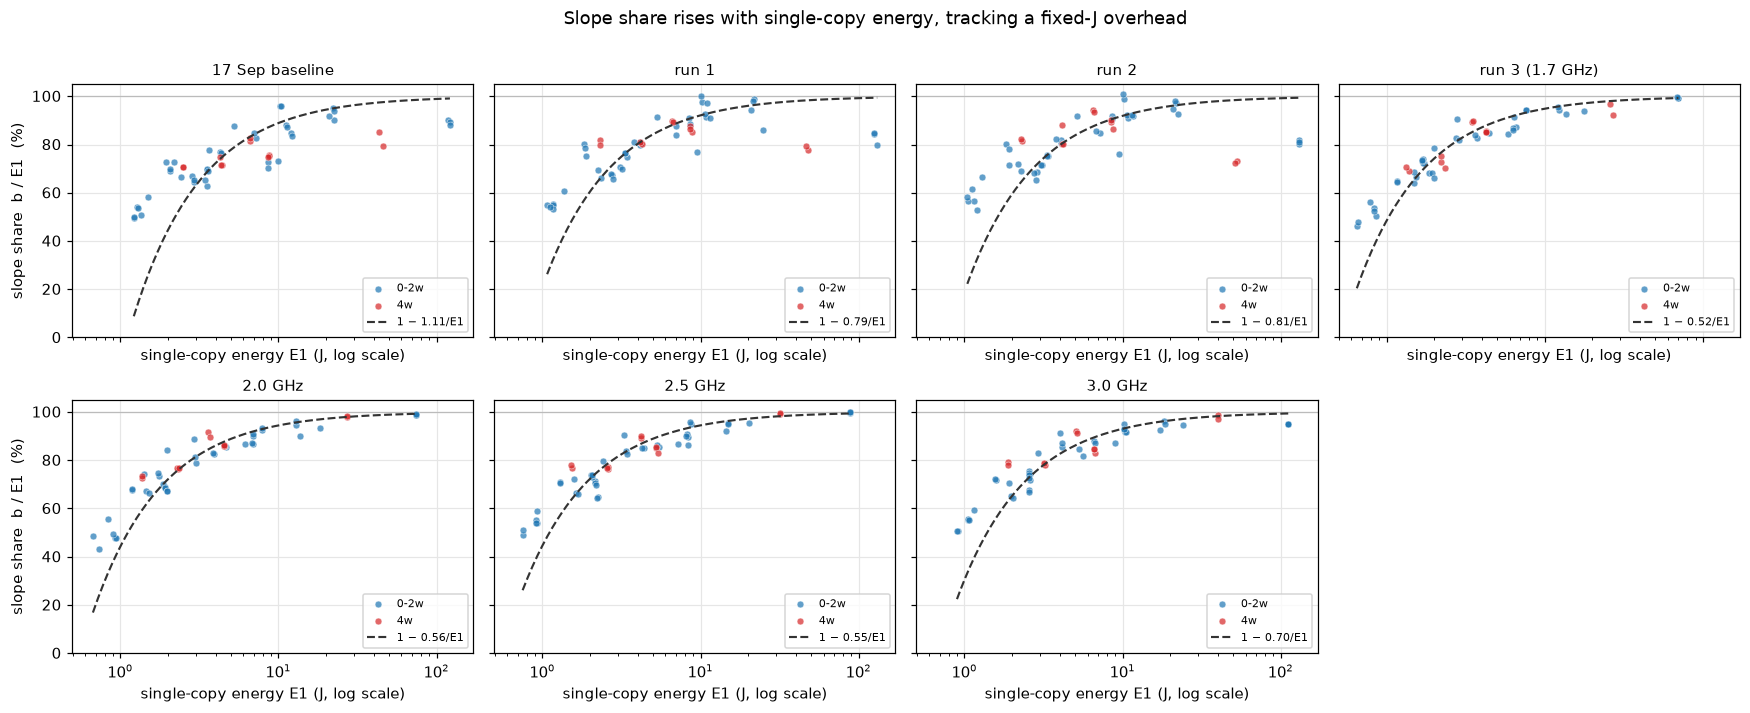

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "savefig.facecolor": "white", "axes.grid": True,
                     "grid.color": "#e6e6e6", "axes.axisbelow": True,
                     "font.size": 9.5, "figure.dpi": 110})
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

runs = list(PERQ)
ncol = 4; nrow = int(np.ceil(len(runs) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.0 * ncol, 3.2 * nrow),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax, lbl in zip(axes, runs):
    d = PERQ[lbl]; Fmed = d["F"].median()
    for cl in ["0-2w", "4w"]:
        s = d[d["wclass"] == cl]
        ax.scatter(s["E1"], 100 * s["slope_share"], s=20, color=WCOLOR[cl],
                   alpha=0.7, edgecolor="white", linewidth=0.4, label=cl, zorder=3)
    xs = np.logspace(np.log10(max(d["E1"].min(), 0.2)), np.log10(d["E1"].max()), 200)
    ax.plot(xs, 100 * (1 - Fmed / xs), color="#333333", lw=1.4, ls="--",
            zorder=4, label=f"1 − {Fmed:.2f}/E1")
    ax.set_xscale("log"); ax.set_title(lbl, fontsize=10)
    ax.set_ylim(0, 105); ax.axhline(100, color="#bbbbbb", lw=0.8, zorder=1)
    ax.legend(fontsize=7, loc="lower right")
for ax in axes[len(runs):]:
    ax.set_visible(False)
for ax in axes:
    if ax.get_visible():
        ax.set_xlabel("single-copy energy E1 (J, log scale)")
for r in range(nrow):
    axes[r * ncol].set_ylabel("slope share  b / E1  (%)")
fig.suptitle("Slope share rises with single-copy energy, tracking a fixed-J overhead",
             fontsize=12, y=1.005)
fig.tight_layout()
fig.savefig(FIG / "slope_share_vs_e1.svg", bbox_inches="tight")
plt.show()

**Example — run 3 (1.7 GHz), sorted by single-copy time.** The three shortest, two middle
and three longest queries. Short queries are almost all overhead (low slope share); long
ones are almost all per-copy work.

In [5]:
d = PERQ["run 3 (1.7 GHz)"].sort_values("t1").reset_index(drop=True)
idx = list(range(3)) + [len(d) // 2 - 1, len(d) // 2] + list(range(len(d) - 3, len(d)))
ex = d.loc[idx, ["qkey", "workers", "t1", "E1", "b", "F", "slope_share"]].copy()
ex["slope_share"] = (100 * ex["slope_share"]).round(1)
ex = ex.rename(columns={"t1": "t1_s", "E1": "E1_J", "b": "b_Jpercopy",
                        "F": "F_J", "slope_share": "slope_share_%"})
print("run 3 (1.7 GHz) — shortest / middle / longest queries:\n")
print(ex.round(3).to_string(index=False))

run 3 (1.7 GHz) — shortest / middle / longest queries:

                   qkey  workers  t1_s   E1_J  b_Jpercopy   F_J  slope_share_%
           q19/base.sql        2 0.135  0.648       0.300 0.349           46.2
q19/v1_materialized.sql        2 0.135  0.655       0.312 0.342           47.7
   q19/v2_union_all.sql        2 0.161  0.832       0.436 0.396           52.4
  q16/v2_not_exists.sql        2 0.508  2.780       2.518 0.262           90.6
q16/v1_materialized.sql        4 0.559  3.498       3.143 0.356           89.8
        q18/v2_join.sql        3 8.027 69.170      68.839 0.331           99.5
q18/v1_materialized.sql        3 8.074 69.682      69.149 0.533           99.2
           q18/base.sql        3 8.083 70.076      69.610 0.466           99.3


## 2. Overhead is a fixed energy, not a fixed fraction

**What this shows.** If the per-process overhead were a fixed *energy* `F`, then `F` should
be roughly constant across queries (and across worker classes), while the *share* it takes
of a single copy should fall as `1/E1`. Three checks: the spread of `F` per run and class,
the average power `P` per class (overhead in joules ≈ a fixed *time* × power, so it tracks
power), and whether the overhead share is better predicted by energy (`1/E1`) than by time
(`1/t1`).

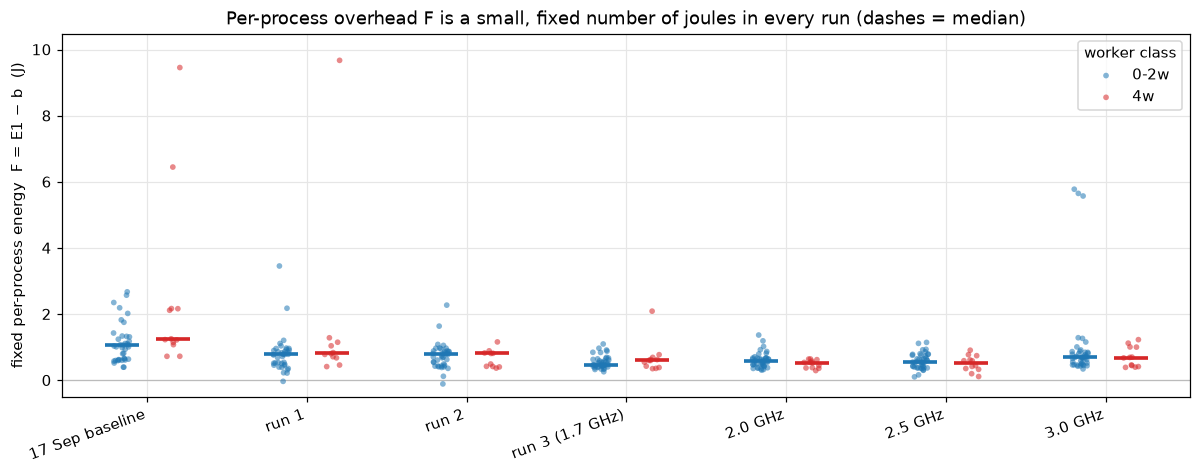

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.4))
runs = list(PERQ)
pos = np.arange(len(runs))
for i, lbl in enumerate(runs):
    d = PERQ[lbl]
    for j, cl in enumerate(["0-2w", "4w"]):
        s = d[d["wclass"] == cl]["F"]
        x = i + (j - 0.5) * 0.32 + np.random.default_rng(j).uniform(-0.05, 0.05, len(s))
        ax.scatter(x, s, s=14, color=WCOLOR[cl], alpha=0.55, edgecolor="none",
                   label=cl if i == 0 else None, zorder=3)
        ax.plot([i + (j - 0.5) * 0.32], [s.median()], marker="_", ms=22, mew=2.4,
                color=WCOLOR[cl], zorder=4)
ax.axhline(0, color="#bbbbbb", lw=0.8)
ax.set_xticks(pos); ax.set_xticklabels(runs, rotation=20, ha="right")
ax.set_ylabel("fixed per-process energy  F = E1 − b  (J)")
ax.set_ylim(-0.5, max(3.0, PQ["F"].quantile(0.97)))
ax.legend(title="worker class", loc="upper right")
ax.set_title("Per-process overhead F is a small, fixed number of joules in every run "
             "(dashes = median)", fontsize=11.5)
fig.tight_layout(); fig.savefig(FIG / "overhead_F_by_class.svg", bbox_inches="tight")
plt.show()

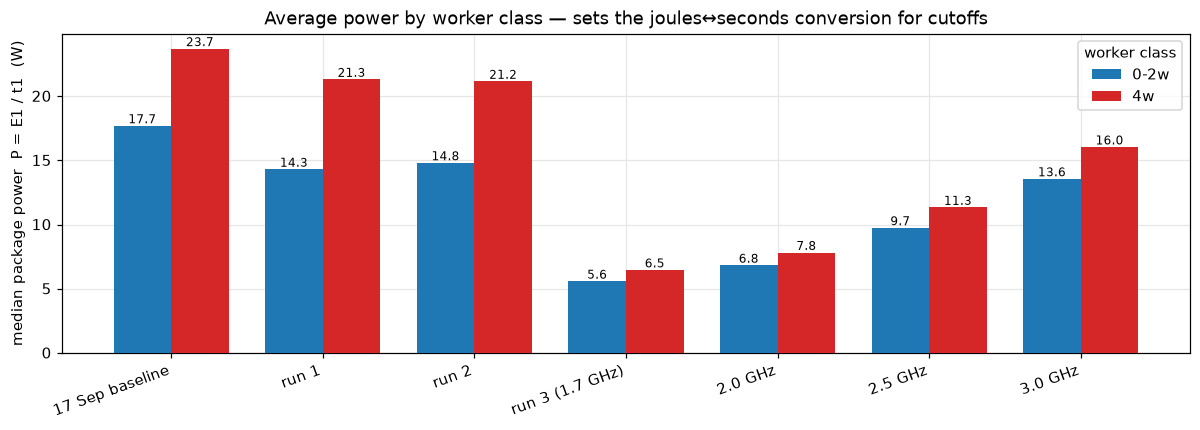

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.0))
runs = list(PERQ); w = 0.38
for j, cl in enumerate(["0-2w", "4w"]):
    vals = [PERQ[lbl][PERQ[lbl]["wclass"] == cl]["P"].median() for lbl in runs]
    ax.bar(np.arange(len(runs)) + (j - 0.5) * w, vals, w, color=WCOLOR[cl],
           label=cl, zorder=3)
    for i, v in enumerate(vals):
        ax.text(i + (j - 0.5) * w, v + 0.2, f"{v:.1f}", ha="center", fontsize=8)
ax.set_xticks(np.arange(len(runs))); ax.set_xticklabels(runs, rotation=20, ha="right")
ax.set_ylabel("median package power  P = E1 / t1  (W)")
ax.legend(title="worker class")
ax.set_title("Average power by worker class — sets the joules↔seconds conversion for cutoffs",
             fontsize=11.5)
fig.tight_layout(); fig.savefig(FIG / "power_by_class.svg", bbox_inches="tight")
plt.show()

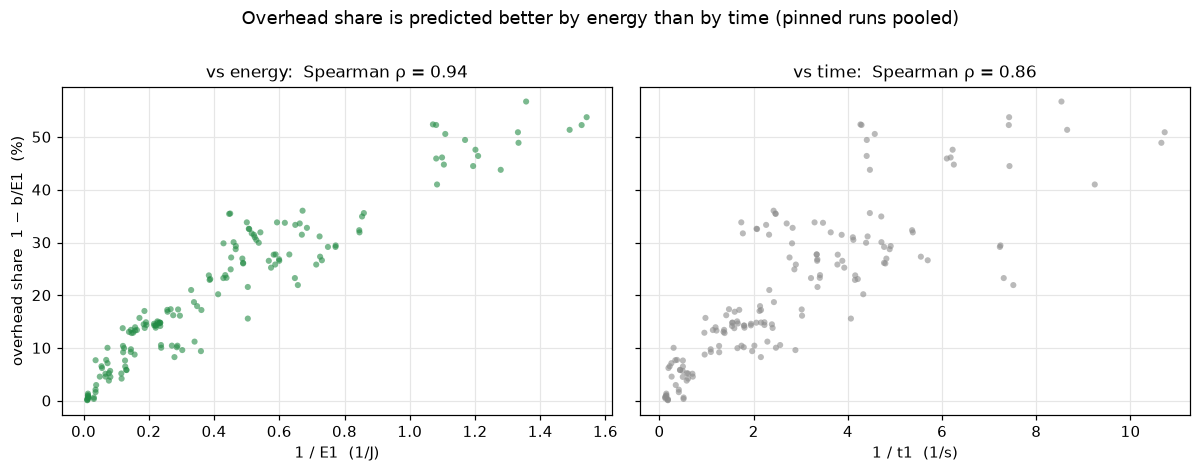

pinned runs pooled (run 3 (1.7 GHz), 2.0 GHz, 2.5 GHz):  ρ(overhead share, 1/E1) = 0.945   >   ρ(overhead share, 1/t1) = 0.861


In [8]:
pin = pd.concat([PERQ[l] for l in PINNED], ignore_index=True)
osh = 1 - pin["b"] / pin["E1"]           # overhead share


def spearman(a, b):
    a = pd.Series(np.asarray(a, float)); b = pd.Series(np.asarray(b, float))
    m = a.notna() & b.notna()
    return a[m].rank().corr(b[m].rank())

rE = spearman(osh, 1 / pin["E1"]); rT = spearman(osh, 1 / pin["t1"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
a1.scatter(1 / pin["E1"], 100 * osh, s=16, color="#238b45", alpha=0.6, edgecolor="none")
a1.set_xlabel("1 / E1  (1/J)"); a1.set_ylabel("overhead share  1 − b/E1  (%)")
a1.set_title(f"vs energy:  Spearman ρ = {rE:.2f}", fontsize=11)
a2.scatter(1 / pin["t1"], 100 * osh, s=16, color="#8c8c8c", alpha=0.6, edgecolor="none")
a2.set_xlabel("1 / t1  (1/s)")
a2.set_title(f"vs time:  Spearman ρ = {rT:.2f}", fontsize=11)
fig.suptitle("Overhead share is predicted better by energy than by time (pinned runs pooled)",
             fontsize=12, y=1.01)
fig.tight_layout(); fig.savefig(FIG / "overhead_share_energy_vs_time.svg", bbox_inches="tight")
plt.show()
print(f"pinned runs pooled ({', '.join(PINNED)}):  ρ(overhead share, 1/E1) = {rE:.3f}"
      f"   >   ρ(overhead share, 1/t1) = {rT:.3f}")

## 3. Energy cutoffs — when is a single copy already accurate?

**What this shows.** For a target slope share `r`, the model cutoff is `E1 ≥ F/(1−r)`:
above it, overhead is at most `1−r` of the reading, so a single copy is within `r` of the
per-copy slope. We report it from the **median F** and the more conservative **75th-pct F**
per run. An empirical check confirms it (smallest `E1` above which ≥90 % of queries reach
share ≥ `r`). Cutoffs convert to **seconds** per worker class via `cutoff / P_class`.
Finally, at 2.5 GHz, an **energy** cutoff is compared with a single **time** cutoff
(`energy cutoff / overall median P`): energy keeps fewer queries that secretly miss `r`.

In [9]:
RS = [0.90, 0.95, 0.99]
rows = []
for lbl in PERQ:
    d = PERQ[lbl]; Fmed = d["F"].median(); F75 = d["F"].quantile(0.75)
    row = {"run": lbl, "F_med_J": round(Fmed, 2), "F_p75_J": round(F75, 2)}
    for r in RS:
        row[f"cut_medF_{int(r*100)}"] = round(Fmed / (1 - r), 1)
        row[f"cut_p75F_{int(r*100)}"] = round(F75 / (1 - r), 1)
    rows.append(row)
CUT_TBL = pd.DataFrame(rows).set_index("run").loc[list(PERQ)]
print("Model energy cutoffs  E1 >= F/(1-r)  (J), from median-F and p75-F:\n")
print(CUT_TBL.to_string())

Model energy cutoffs  E1 >= F/(1-r)  (J), from median-F and p75-F:

                 F_med_J  F_p75_J  cut_medF_90  cut_p75F_90  cut_medF_95  cut_p75F_95  cut_medF_99  cut_p75F_99
run                                                                                                            
17 Sep baseline     1.11     1.83         11.1         18.3         22.2         36.6        111.0        183.1
run 1               0.79     0.98          7.9          9.8         15.8         19.5         79.0         97.7
run 2               0.81     0.95          8.1          9.5         16.2         19.1         81.0         95.3
run 3 (1.7 GHz)     0.52     0.63          5.2          6.3         10.3         12.7         51.6         63.4
2.0 GHz             0.56     0.66          5.6          6.6         11.2         13.1         55.8         65.6
2.5 GHz             0.55     0.75          5.5          7.5         11.1         15.0         55.4         74.8
3.0 GHz             0.70     0.87   

In [10]:
def empirical_cutoff(d, r, frac=0.90):
    """smallest E1 threshold at/above which >=frac of queries reach slope_share>=r."""
    d = d.sort_values("E1")
    for tau in d["E1"].values:
        sub = d[d["E1"] >= tau]
        if len(sub) >= 3 and (sub["slope_share"] >= r).mean() >= frac:
            return tau, len(sub)
    return np.nan, 0

rows = []
for lbl in PERQ:
    d = PERQ[lbl]; row = {"run": lbl}
    for r in RS:
        tau, n = empirical_cutoff(d, r)
        row[f"emp_E1_{int(r*100)}"] = round(tau, 1) if np.isfinite(tau) else np.nan
        row[f"n_above_{int(r*100)}"] = n
    rows.append(row)
EMP_TBL = pd.DataFrame(rows).set_index("run").loc[list(PERQ)]
print("Empirical cutoff: smallest E1 above which >=90% of queries reach share>=r "
      "(and the count above it):\n")
print(EMP_TBL.to_string())

Empirical cutoff: smallest E1 above which >=90% of queries reach share>=r (and the count above it):

                 emp_E1_90  n_above_90  emp_E1_95  n_above_95  emp_E1_99  n_above_99
run                                                                                 
17 Sep baseline        NaN           0        NaN           0        NaN           0
run 1                  NaN           0        NaN           0        NaN           0
run 2                  NaN           0        NaN           0        NaN           0
run 3 (1.7 GHz)        6.4          13       69.2           3       69.2           3
2.0 GHz                6.9          13       27.2           5        NaN           0
2.5 GHz                8.3          12       20.1           6       31.7           5
3.0 GHz                8.9          16        NaN           0        NaN           0


In [11]:
rows = []
for lbl in PERQ:
    d = PERQ[lbl]; F75 = d["F"].quantile(0.75)
    P4 = d[d["wclass"] == "4w"]["P"].median()
    P02 = d[d["wclass"] == "0-2w"]["P"].median()
    for r in RS:
        cut = F75 / (1 - r)
        rows.append(dict(run=lbl, r=f"{int(r*100)}%", cutoff_J=round(cut, 1),
                         t_4w_s=round(cut / P4, 2), t_0to2w_s=round(cut / P02, 2)))
TE = pd.DataFrame(rows)
print("Time equivalents of the p75-F cutoffs, per worker class  (cutoff / P_class):\n")
print(TE.to_string(index=False))

Time equivalents of the p75-F cutoffs, per worker class  (cutoff / P_class):



            run   r  cutoff_J  t_4w_s  t_0to2w_s
17 Sep baseline 90%      18.3    0.77       1.03
17 Sep baseline 95%      36.6    1.55       2.07
17 Sep baseline 99%     183.1    7.73      10.35
          run 1 90%       9.8    0.46       0.68
          run 1 95%      19.5    0.92       1.37
          run 1 99%      97.7    4.58       6.83
          run 2 90%       9.5    0.45       0.64
          run 2 95%      19.1    0.90       1.29
          run 2 99%      95.3    4.50       6.43
run 3 (1.7 GHz) 90%       6.3    0.98       1.14
run 3 (1.7 GHz) 95%      12.7    1.96       2.27
run 3 (1.7 GHz) 99%      63.4    9.82      11.37
        2.0 GHz 90%       6.6    0.84       0.96
        2.0 GHz 95%      13.1    1.68       1.92
        2.0 GHz 99%      65.6    8.39       9.62
        2.5 GHz 90%       7.5    0.66       0.77
        2.5 GHz 95%      15.0    1.32       1.53
        2.5 GHz 99%      74.8    6.60       7.67
        3.0 GHz 90%       8.7    0.54       0.64
        3.0 GHz 95%

2.5 GHz — energy cutoff vs single time cutoff (overall median P = 10.4 W):

  r  E_cut_J  t_cut_s  energy_keeps  energy_miss  time_keeps  time_miss
90%      7.5     0.72            15            2          14          2
95%     15.0     1.44             6            0           9          2
99%     74.8     7.20             3            0           0          0


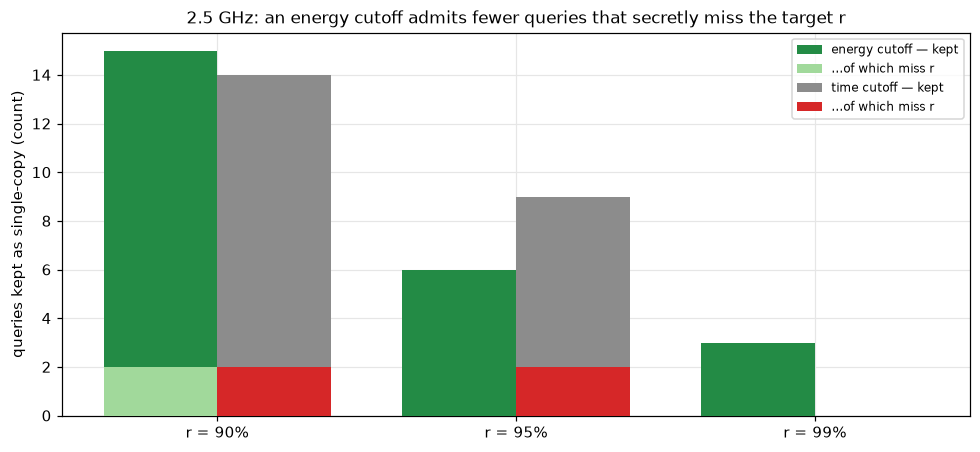

In [12]:
# 2.5 GHz: energy cutoff vs one time cutoff (energy cutoff / overall median P)
d = PERQ["2.5 GHz"]; F75 = d["F"].quantile(0.75); Pmed = d["P"].median()
rows = []
for r in RS:
    Ecut = F75 / (1 - r); Tcut = Ecut / Pmed
    keepE = d[d["E1"] >= Ecut]; keepT = d[d["t1"] >= Tcut]
    rows.append(dict(r=f"{int(r*100)}%", E_cut_J=round(Ecut, 1), t_cut_s=round(Tcut, 2),
                     energy_keeps=len(keepE), energy_miss=int((keepE["slope_share"] < r).sum()),
                     time_keeps=len(keepT), time_miss=int((keepT["slope_share"] < r).sum())))
CMP = pd.DataFrame(rows)
print(f"2.5 GHz — energy cutoff vs single time cutoff (overall median P = {Pmed:.1f} W):\n")
print(CMP.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(CMP)); w = 0.38
ax.bar(x - w/2, CMP["energy_keeps"], w, color="#238b45", label="energy cutoff — kept", zorder=3)
ax.bar(x - w/2, CMP["energy_miss"], w, color="#a1d99b", label="…of which miss r", zorder=4)
ax.bar(x + w/2, CMP["time_keeps"], w, color="#8c8c8c", label="time cutoff — kept", zorder=3)
ax.bar(x + w/2, CMP["time_miss"], w, color="#d62728", label="…of which miss r", zorder=4)
ax.set_xticks(x); ax.set_xticklabels([f"r = {v}" for v in CMP["r"]])
ax.set_ylabel("queries kept as single-copy (count)")
ax.legend(fontsize=8)
ax.set_title("2.5 GHz: an energy cutoff admits fewer queries that secretly miss the target r",
             fontsize=11)
fig.tight_layout(); fig.savefig(FIG / "energy_vs_time_cutoff_2p5.svg", bbox_inches="tight")
plt.show()

## 4. Thermal caveat — heavy queries in turbo runs

**What this shows.** The heaviest queries are exactly where `N=1` should be most accurate
(overhead is a tiny share), yet in the **turbo** runs (baseline, run 1, run 2) their slope
share sits at only ~72–85 %. That is *not* overhead: at large `N` the package throttles, so
per-copy energy at `N=16` is **lower** than at `N=1`, which bends the fit and drops the
slope below `E1`. Capping the clock removes it — `q18` climbs from ~95 % at 3.0 GHz to ~100 %
at 2.5 GHz. So for the heaviest queries, throttling (a real physical effect at large `N`),
not per-process overhead, is what a low slope share is measuring in the uncapped runs.

In [13]:
heavy_fams = ["q18", "q01"]
rows = []
for lbl in PERQ:
    d = PERQ[lbl].sort_values("E1", ascending=False).head(8)
    for _, rrow in d.iterrows():
        rows.append(dict(run=lbl, qkey=rrow["qkey"], workers=rrow["workers"],
                         E1_J=round(rrow["E1"], 1),
                         slope_share_pct=round(100 * rrow["slope_share"], 1)))
HEAVY = pd.DataFrame(rows)
print("Eight most energetic queries per run (worker count, E1, slope share):\n")
for lbl in PERQ:
    print(f"--- {lbl} ---")
    print(HEAVY[HEAVY["run"] == lbl][["qkey", "workers", "E1_J", "slope_share_pct"]]
          .to_string(index=False))
    print()

Eight most energetic queries per run (worker count, E1, slope share):

--- 17 Sep baseline ---
                   qkey  workers  E1_J  slope_share_pct
        q18/v2_join.sql        3 121.5             88.3
q18/v1_materialized.sql        3 120.8             89.3
           q18/base.sql        3 118.7             90.3
q01/v1_materialized.sql        4  46.1             79.5
           q01/base.sql        4  43.2             85.1
q09/v1_materialized.sql        2  22.3             94.0
  q13/v2_correlated.sql        0  22.3             90.2
           q09/base.sql        2  22.1             95.0

--- run 1 ---
                   qkey  workers  E1_J  slope_share_pct
           q18/base.sql        3 131.1             79.8
q18/v1_materialized.sql        3 125.4             84.3
        q18/v2_join.sql        3 124.9             84.8
           q01/base.sql        4  47.9             77.9
q01/v1_materialized.sql        4  46.5             79.2
  q13/v2_correlated.sql        0  24.7            

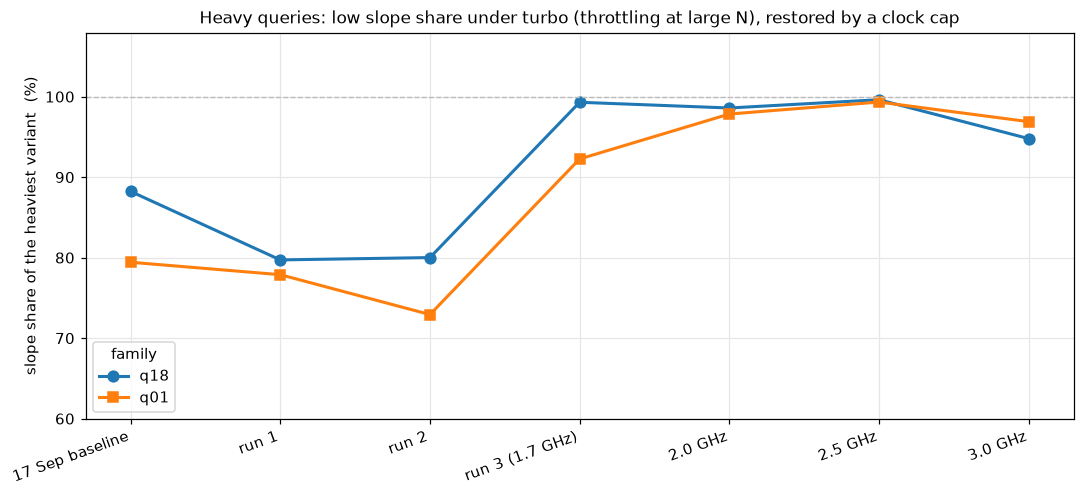

In [14]:
# track the same heavy families across the run ladder
fig, ax = plt.subplots(figsize=(10, 4.6))
runs = list(PERQ)
for fam, mk in zip(heavy_fams, ["o", "s"]):
    ys = []
    for lbl in runs:
        d = PERQ[lbl]; s = d[d["family"] == fam]
        ys.append(100 * s.sort_values("E1").iloc[-1]["slope_share"] if len(s) else np.nan)
    ax.plot(range(len(runs)), ys, marker=mk, lw=2, ms=7, label=fam)
ax.axhline(100, color="#bbbbbb", lw=0.9, ls="--")
ax.set_xticks(range(len(runs))); ax.set_xticklabels(runs, rotation=20, ha="right")
ax.set_ylabel("slope share of the heaviest variant  (%)")
ax.set_ylim(60, 108); ax.legend(title="family")
ax.set_title("Heavy queries: low slope share under turbo (throttling at large N), "
             "restored by a clock cap", fontsize=11)
fig.tight_layout(); fig.savefig(FIG / "thermal_heavy_slope_share.svg", bbox_inches="tight")
plt.show()

## 5. Noise floor of a single copy (2.5 GHz)

**What this shows.** A cutoff is only useful if a single-copy reading is *repeatable*.
Across the 3 restart repeats at 2.5 GHz, the coefficient of variation (CV) of the `N=1`
energy is tiny — a couple of percent overall and a few tenths of a percent for the heavy
queries the cutoff keeps as single copies.

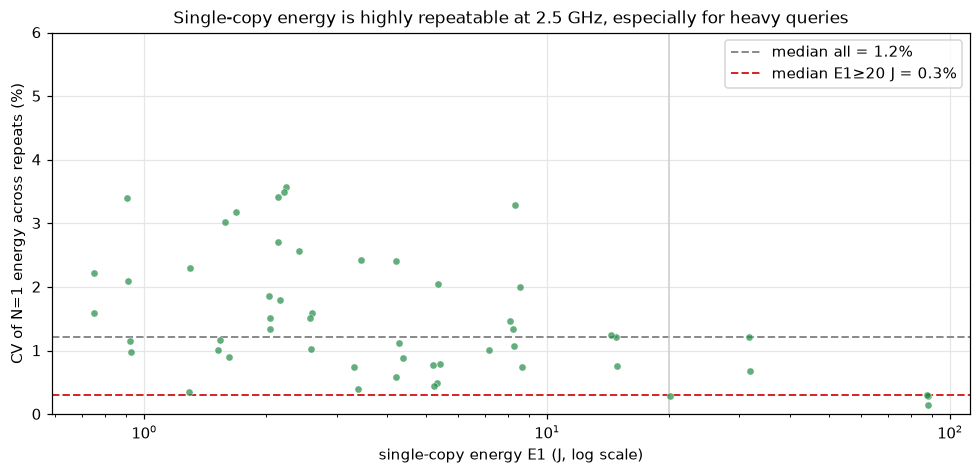

N=1 energy CV at 2.5 GHz: median all = 1.22%   |   median for E1>=20 J = 0.30%


In [15]:
t = TIMING["2.5 GHz"]
n1 = t[t["batchnum"] == 1]
cv = n1.groupby("qkey")["rapl_pkg_j"].agg(
    lambda x: 100 * x.std(ddof=1) / x.mean() if len(x) >= 2 else np.nan)
E1 = n1.groupby("qkey")["rapl_pkg_j"].mean()
cvdf = pd.DataFrame({"E1": E1, "cv": cv}).dropna()

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.scatter(cvdf["E1"], cvdf["cv"], s=22, color="#238b45", alpha=0.7,
           edgecolor="white", linewidth=0.4, zorder=3)
m_all = cvdf["cv"].median(); m_hi = cvdf[cvdf["E1"] >= 20]["cv"].median()
ax.axhline(m_all, color="#8c8c8c", lw=1.3, ls="--", label=f"median all = {m_all:.1f}%")
ax.axhline(m_hi, color="#d62728", lw=1.3, ls="--", label=f"median E1≥20 J = {m_hi:.1f}%")
ax.axvline(20, color="#cccccc", lw=1.0)
ax.set_xscale("log"); ax.set_xlabel("single-copy energy E1 (J, log scale)")
ax.set_ylabel("CV of N=1 energy across repeats (%)")
ax.set_ylim(0, max(6, cvdf["cv"].quantile(0.95))); ax.legend()
ax.set_title("Single-copy energy is highly repeatable at 2.5 GHz, especially for heavy queries",
             fontsize=11)
fig.tight_layout(); fig.savefig(FIG / "noise_floor_2p5.svg", bbox_inches="tight")
plt.show()
print(f"N=1 energy CV at 2.5 GHz: median all = {m_all:.2f}%   |   "
      f"median for E1>=20 J = {m_hi:.2f}%")

## 6. Two-point slope error vs the top batch size

**What this shows.** Instead of the full fit, estimate the per-copy energy from just two
points — the `N=1` batch and one larger batch `N` — within the *same* restart repeat:
`s_N = (E_N − E_1)/(N − 1)`. The error `|s_N − b|/b` is how far a `{1,N}` design lands from
the full-fit slope `b`. Grouped by `E1` band, it shows how large a top batch each band needs.
We also show the **plain batch average** `E_N/N`, which still carries the overhead and is
biased high. Because the full-fit `b` includes the `N=16` points (and so flatters `{1,16}`),
the robustness panel refits `b` **without** the repeat being tested (leave-one-repeat-out).
The heatmap's leftmost column, **`{1}`**, is the single copy used *alone* as the per-copy
estimate (error `|E1 − b|/b`) — the baseline the two-point designs improve on.

In [16]:
def two_point_errors(runs, loo=False):
    rows = []
    for lbl in runs:
        t = TIMING[lbl]
        for qkey, g in t.groupby("qkey"):
            b_full, _ = ols(g["batchnum"], g["rapl_pkg_j"])
            E1band = g[g["batchnum"] == 1]["rapl_pkg_j"].mean()
            if not np.isfinite(b_full) or b_full <= 0 or not np.isfinite(E1band):
                continue
            band = e1_band(E1band)
            for rid, gr in g.groupby("run_id"):
                e = gr.groupby("batchnum")["rapl_pkg_j"].mean()
                if 1 not in e.index:
                    continue
                e1 = e.loc[1]
                bref = b_full
                if loo:
                    gl = g[g["run_id"] != rid]
                    bref, _ = ols(gl["batchnum"], gl["rapl_pkg_j"])
                    if not np.isfinite(bref) or bref <= 0:
                        continue
                # N=1: the single copy used *alone* as the per-copy estimate (sN = E1)
                rows.append(dict(run=lbl, qkey=qkey, band=band, N=1,
                                 err=abs(e1 - bref) / bref,
                                 err_avg=abs(e1 - bref) / bref))
                for N in (2, 4, 8, 16):
                    if N not in e.index:
                        continue
                    sN = (e.loc[N] - e1) / (N - 1)
                    avgN = e.loc[N] / N
                    rows.append(dict(run=lbl, qkey=qkey, band=band, N=N,
                                     err=abs(sN - bref) / bref,
                                     err_avg=abs(avgN - bref) / bref))
    return pd.DataFrame(rows)

TP = two_point_errors(PINNED, loo=False)


def err_table(df, col="err"):
    out = {}
    for bn in BAND_ORDER:
        sub = df[df["band"] == bn]
        cells = {}
        for N in (2, 4, 8, 16):
            s = sub[sub["N"] == N][col] * 100
            cells[f"{{1,{N}}}"] = (f"{s.median():.1f} ({s.quantile(0.9):.1f})"
                                   if len(s) else "-")
        cells["query-runs"] = sub[sub["N"] == 2]["qkey"].count()
        out[bn] = cells
    return pd.DataFrame(out).T

print("Two-point slope error, median (90th pct) % — full-fit reference, pinned runs:\n")
print(err_table(TP, "err").to_string())
print("\nPlain batch-average estimator E_N/N vs b, median (90th pct) % — biased by overhead:\n")
print(err_table(TP, "err_avg").to_string())

Two-point slope error, median (90th pct) % — full-fit reference, pinned runs:

             {1,2}      {1,4}      {1,8}     {1,16} query-runs
<2      4.4 (13.5)  2.7 (7.9)  1.5 (4.0)  0.6 (1.8)        171
2-7.5   2.8 (10.0)  1.2 (3.3)  0.8 (2.3)  0.4 (1.3)        195
7.5-15   1.4 (4.7)  0.7 (2.3)  0.9 (1.9)  0.4 (1.7)         57
15-75    0.7 (2.0)  0.6 (2.3)  0.4 (1.1)  0.3 (0.8)         45
>75      0.6 (1.1)  0.7 (0.9)  0.4 (0.7)  0.1 (0.3)          9

Plain batch-average estimator E_N/N vs b, median (90th pct) % — biased by overhead:

              {1,2}        {1,4}       {1,8}     {1,16} query-runs
<2      24.1 (51.6)  12.0 (26.0)  6.7 (14.3)  3.1 (6.8)        171
2-7.5    9.1 (18.9)    4.7 (9.0)   2.4 (4.9)  1.3 (2.8)        195
7.5-15    3.6 (6.7)    2.0 (3.5)   1.2 (2.3)  0.7 (1.8)         57
15-75     1.0 (4.3)    0.7 (3.0)   0.6 (1.1)  0.4 (0.8)         45
>75       0.3 (0.4)    0.5 (0.6)   0.4 (0.6)  0.1 (0.3)          9


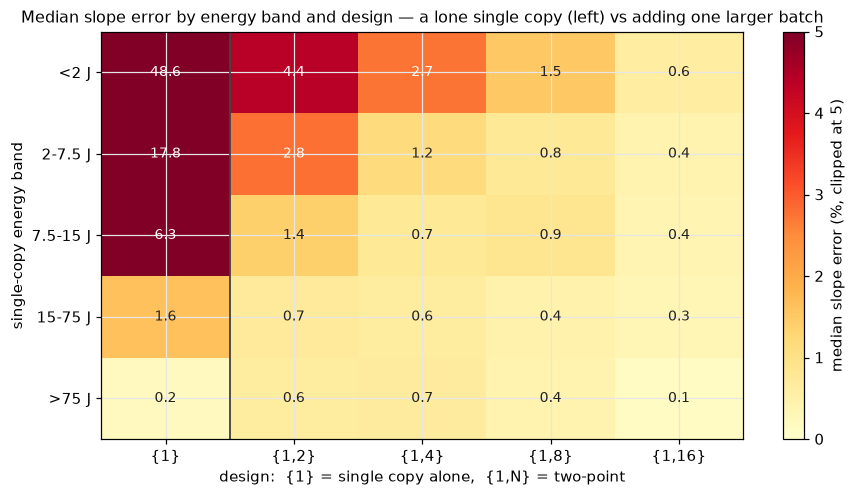

In [17]:
# heatmap of median slope error; {1} = the single copy used alone, then {1,N} two-point
HN = (1, 2, 4, 8, 16)
HLBL = ["{1}"] + [f"{{1,{N}}}" for N in HN[1:]]
M = np.array([[TP[(TP["band"] == bn) & (TP["N"] == N)]["err"].median() * 100
               for N in HN] for bn in BAND_ORDER])
fig, ax = plt.subplots(figsize=(8.4, 4.6))
im = ax.imshow(M, aspect="auto", cmap="YlOrRd", vmin=0, vmax=5)
ax.set_xticks(range(len(HN))); ax.set_xticklabels(HLBL)
ax.set_yticks(range(len(BAND_ORDER))); ax.set_yticklabels([f"{b} J" for b in BAND_ORDER])
ax.set_xlabel("design:  {1} = single copy alone,  {1,N} = two-point")
ax.set_ylabel("single-copy energy band")
ax.axvline(0.5, color="#444444", lw=1.2)      # separate {1} from the two-point columns
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                color="white" if v > 2.7 else "#222222", fontsize=9)
cb = fig.colorbar(im, ax=ax); cb.set_label("median slope error (%, clipped at 5)")
ax.set_title("Median slope error by energy band and design — a lone single copy (left) "
             "vs adding one larger batch", fontsize=10.5)
fig.tight_layout(); fig.savefig(FIG / "twopoint_error_heatmap.svg", bbox_inches="tight")
plt.show()

In [18]:
TP_LOO = two_point_errors(PINNED, loo=True)
print("Robustness — leave-one-repeat-out reference (b refit without the tested repeat):\n")
print(err_table(TP_LOO, "err").to_string())

Robustness — leave-one-repeat-out reference (b refit without the tested repeat):

             {1,2}      {1,4}      {1,8}     {1,16} query-runs
<2      4.2 (13.7)  2.7 (8.6)  1.6 (4.2)  0.9 (2.9)        171
2-7.5    2.8 (9.9)  1.2 (3.7)  0.9 (2.4)  0.6 (1.9)        195
7.5-15   1.5 (4.4)  0.8 (2.0)  1.0 (2.2)  0.6 (2.5)         57
15-75    0.8 (2.2)  0.6 (2.4)  0.5 (1.2)  0.5 (1.1)         45
>75      0.6 (1.1)  0.7 (1.0)  0.4 (0.8)  0.2 (0.5)          9


## 7. Batch-size tiers

**What this shows.** Turning §6 into a rule: the smallest top batch `N` each energy band
needs. **99 %** requires the median two-point error ≤ 1 %; **95 %** requires the 90th-pct
error ≤ 5 %. Queries above 75 J are single copies only (they are already at/above 99 %). We
then check the shorthand *top N × E1 ≳ 30 J for 99 %, ≳ 10–15 J for 95 %*.

In [19]:
def tiers(df):
    rows = []
    for bn in BAND_ORDER:
        sub = df[df["band"] == bn]
        n99 = n95 = "single"
        if bn != ">75":
            for N in (2, 4, 8, 16):
                s = sub[sub["N"] == N]["err"] * 100
                if len(s) and s.median() <= 1.0:
                    n99 = N; break
            for N in (2, 4, 8, 16):
                s = sub[sub["N"] == N]["err"] * 100
                if len(s) and s.quantile(0.9) <= 5.0:
                    n95 = N; break
        rows.append(dict(band_J=bn, top_N_99=n99, top_N_95=n95))
    return pd.DataFrame(rows).set_index("band_J")

TIER = tiers(TP)
print("Batch-size tiers (top N per band):\n")
print(TIER.to_string())

# rule-of-thumb check: top N * (band lower edge / representative E1)
print("\nRule check  top_N x E1 (using band lower edge, and median E1 in band at 2.5 GHz):")
d25 = PERQ["2.5 GHz"]
for bn, lo, hi in [("<2", 0.5, 2), ("2-7.5", 2, 7.5), ("7.5-15", 7.5, 15),
                   ("15-75", 15, 75)]:
    medE = d25[d25["band"] == bn]["E1"].median()
    for tier_col, tag in [("top_N_99", "99%"), ("top_N_95", "95%")]:
        N = TIER.loc[bn, tier_col]
        if isinstance(N, str):
            continue
        print(f"  {bn:7} {tag}: N={N}  ->  N*lo = {N*lo:.0f} J,  "
              f"N*medE1 = {N*medE:.0f} J")

Batch-size tiers (top N per band):

       top_N_99 top_N_95
band_J                  
<2           16        8
2-7.5         8        4
7.5-15        4        2
15-75         2        2
>75      single   single

Rule check  top_N x E1 (using band lower edge, and median E1 in band at 2.5 GHz):
  <2      99%: N=16  ->  N*lo = 8 J,  N*medE1 = 21 J
  <2      95%: N=8  ->  N*lo = 4 J,  N*medE1 = 10 J
  2-7.5   99%: N=8  ->  N*lo = 16 J,  N*medE1 = 26 J
  2-7.5   95%: N=4  ->  N*lo = 8 J,  N*medE1 = 13 J
  7.5-15  99%: N=4  ->  N*lo = 30 J,  N*medE1 = 34 J
  7.5-15  95%: N=2  ->  N*lo = 15 J,  N*medE1 = 17 J
  15-75   99%: N=2  ->  N*lo = 30 J,  N*medE1 = 63 J
  15-75   95%: N=2  ->  N*lo = 30 J,  N*medE1 = 63 J


## 8. SQLStorm suite (only if cached)

**What this shows.** The 17,036-query SQLStorm suite (one single-copy measured batch per
query, 2.5 GHz cap, 15 s statement timeout) tells us how the TPC-H-derived cutoffs and
tiers land on a realistic query mix. This section **skips cleanly** if the suite is not in
the cache yet (it may still be running).

SQLStorm: 695 measured rows, failed (15 s timeout) rate = 7.6%; 642 passing queries.


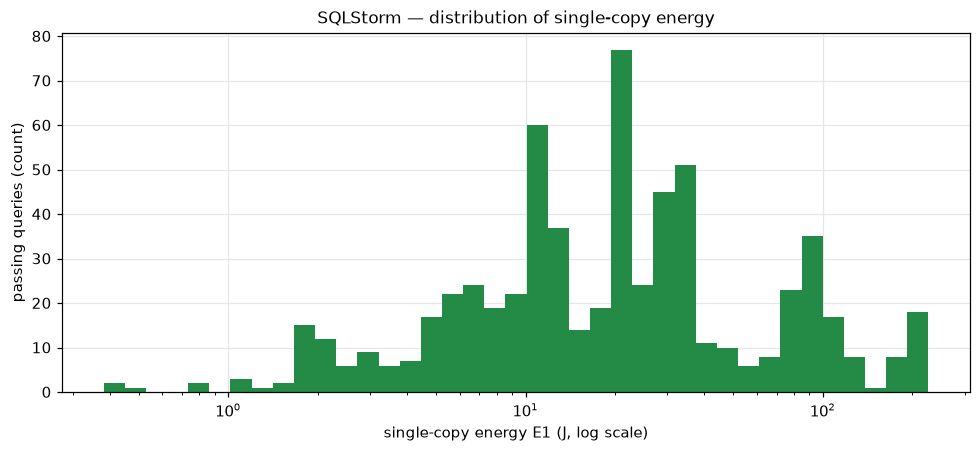

  share of passing queries with E1 >=  7.5 J: 80%
  share of passing queries with E1 >=   15 J: 57%
  share of passing queries with E1 >=   75 J: 16%

  copies: tiered 3008 vs uniform {1,16} 10914 (28% of uniform)
  time-weighted: tiered 4580 s vs uniform 31747 s (14% of uniform)


In [20]:
def find_sqlstorm():
    for key in BLOBS:
        low = key.lower()
        if "sqlstorm" in low and key.endswith(".csv") and "timing" in low:
            return key
    return None

SS_KEY = find_sqlstorm()
if SS_KEY is None:
    print("SQLStorm not in cache yet — section skipped cleanly.")
else:
    ss = pd.read_csv(io.BytesIO(BLOBS[SS_KEY]))
    for c in ["batchnum", "elapsed_sec", "rapl_pkg_j", "failed"]:
        if c in ss.columns:
            ss[c] = pd.to_numeric(ss[c], errors="coerce")
    ss = ss[ss["phase"] == "measured"] if "phase" in ss.columns else ss
    total = len(ss)
    failed_rate = 100 * (ss["failed"].fillna(0) == 1).mean()
    ok = ss[(ss["failed"].fillna(0) != 1) & (ss["rapl_pkg_j"] > 0)].copy()
    ok["qkey"] = _qkey(ok["query"])
    e1 = ok.groupby("qkey")["rapl_pkg_j"].mean()
    t1 = ok.groupby("qkey")["elapsed_sec"].mean()
    print(f"SQLStorm: {total} measured rows, failed (15 s timeout) rate = {failed_rate:.1f}%; "
          f"{len(e1)} passing queries.")

    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.hist(e1[e1 > 0], bins=np.logspace(np.log10(max(e1.min(), 0.1)),
            np.log10(e1.max()), 40), color="#238b45")
    ax.set_xscale("log"); ax.set_xlabel("single-copy energy E1 (J, log scale)")
    ax.set_ylabel("passing queries (count)")
    ax.set_title("SQLStorm — distribution of single-copy energy", fontsize=11)
    fig.tight_layout(); fig.savefig(FIG / "sqlstorm_e1_hist.svg", bbox_inches="tight")
    plt.show()

    for c in (7.5, 15, 75):
        print(f"  share of passing queries with E1 >= {c:>4} J: {100*(e1>=c).mean():.0f}%")

    # tiering saving vs uniform {1,16}
    def tier_N(e):
        b = e1_band(e)
        n = TIER.loc[b, "top_N_99"] if b in TIER.index else "single"
        return 0 if n == "single" else int(n)
    Ntier = e1.map(tier_N)
    copies_tier = (1 + Ntier).sum(); copies_uniform = 17 * len(e1)
    tw_tier = (t1 * (1 + Ntier)).sum(); tw_uniform = (t1 * 17).sum()
    print(f"\n  copies: tiered {copies_tier} vs uniform {{1,16}} {copies_uniform} "
          f"({100*copies_tier/copies_uniform:.0f}% of uniform)")
    print(f"  time-weighted: tiered {tw_tier:.0f} s vs uniform {tw_uniform:.0f} s "
          f"({100*tw_tier/tw_uniform:.0f}% of uniform)")

## 9. Conclusions

* A single-copy reading is **overhead + one copy**; the overhead is a **fixed ~0.5–1 J**
  per process (lower once the clock is pinned), so it takes a *smaller share* of heavier
  queries. Its share is predicted by **energy** (`1/E1`, ρ≈0.94) far better than by time
  (`1/t1`, ρ≈0.87) — energy is the right axis for a cutoff.
* **Cutoffs (2.5 GHz, p75-F):** `E1 ≥ 7.5 / 15 / 75 J` for `90 / 95 / 99 %` slope accuracy
  from a single copy. An **energy** cutoff admits fewer queries that secretly miss the
  target than a single **time** cutoff.
* **Tiers** for lighter queries (top batch `N`): 99 % → `16 / 8 / 4 / 2 / single` across the
  `<2 / 2-7.5 / 7.5-15 / 15-75 / >75 J` bands; 95 % → `8 / 4 / 2 / 2 / single`. Roughly,
  `top_N × E1 ≳ 30 J` buys 99 %, `≳ 10–15 J` buys 95 %.
* **Caveats:** in **turbo** runs the heaviest queries throttle at large `N`, depressing the
  slope below `E1` (not overhead) — a clock cap fixes it. Single-copy energy is highly
  repeatable at 2.5 GHz (CV ≈ 1.2 % overall, 0.3 % for `E1 ≥ 20 J`).